## 0. Constants/Imports

In [64]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.systematics import Systematics
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from sbnd.plotlibrary import makeplot


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [140]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

BASE_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PNFS_BASE_DIR = '/pnfs/sbnd/scratch/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
DET_SYST_DIR = f'{BASE_DIR}/data/2026_01_18/syst/lowz'
RW_SYST_DIR = f'{BASE_DIR}/data/2026_01_18/syst'
PLOT_DIR = f'{BASE_DIR}/plots/{day}/xsec'
SAVE_DIR = f'{BASE_DIR}/data/{day}/xsec'
os.makedirs(SAVE_DIR,exist_ok=True)

In [23]:
MC_FNAME = f'{BASE_DIR}/mc_syst/v4/mc_smallpand_fullsyst_cut_norecomb.df'
MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df'
OFFBEAM_FNAME = f'{BASE_DIR}/offbeam/v4/data_small_nocuts.df'
DATA_FNAME = f'{BASE_DIR}/data/v4/dataonbeam_nocuts.df'

## 1. Load Data

### 1.1. Get keys for h5 files

In [8]:
# Get keys for h5 files
import h5py
mcnu_keys = []

#Slices - selected
mc_sel_pand_keys = []
mc_sel_lowe_pand_keys = []

#Slices - signal
mc_sig_pand_keys = []
mc_sig_lowe_pand_keys = []

#Other slices
offbeam_pand_keys = []
data_pand_keys = []

#Headers
hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
data_hdr_keys = []

#POT and total event keys
mc_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
data_pot_keys = []

mc_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
data_genevt_keys = []
# Check the keys in the H5 Files
for fname in [MC_FNAME,OFFBEAM_FNAME,DATA_FNAME,MC_LOWE_FNAME]:
  print(f'File: {fname}')
  with h5py.File(f'{fname}', 'r') as f:
    # Store all keys at the root level
    for key in f.keys():
      if 'selected' in key:
        if fname == MC_FNAME:
          mc_sel_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_sel_lowe_pand_keys.append(key)
      elif 'signal' in key:
        if fname == MC_FNAME:
          mc_sig_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_sig_lowe_pand_keys.append(key)
      elif 'pand' in key:
        if fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
      elif 'mcnu' in key:
        if fname == MC_FNAME:
          mcnu_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mcnu_lowe_keys.append(key)
      elif 'hdr' in key:
        if fname == MC_FNAME:
          hdr_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
      elif 'histpotdf' in key:
        if fname == MC_FNAME:
          mc_pot_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
      elif 'histgenevtdf' in key:
        if fname == MC_FNAME:
          mc_genevt_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_smallpand_fullsyst_cut_norecomb.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v4/data_small_nocuts.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v4/dataonbeam_nocuts.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df


In [9]:
#Get POT from the h5
POT_MC = 0
for key in mc_pot_keys:
  potdf_mc = pd.read_hdf(MC_FNAME,key=key)
  POT_MC += potdf_mc.TotalPOT.values.sum()
print(f'POT_MC: {POT_MC:.2e}')

POT_MC_LOWE = 0
for key in mc_lowe_pot_keys:
  potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
# for key in mc_lowe_hdr_keys:
#   potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

LIVETIME_OFFBEAM = 0
# For MC
# for key in offbeam_genevt_keys:
#   genevt_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# For data
for key in offbeam_hdr_keys:
  hdr_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += hdr_offbeam.noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = pd.read_hdf(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')

#print('WARNING: Setting LIVETIME_OFFBEAM to LIVETIME_DATA for now')
#LIVETIME_OFFBEAM = LIVETIME_DATA

POT_MC: 1.50e+18
POT_MC_LOWE: 6.01e+18
LIVETIME_OFFBEAM: 1.99e+06
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [10]:
slc_mc_sel = CAFSlice.load(MC_FNAME,key=mc_sel_pand_keys,pot=POT_MC)
slc_mc_sig = CAFSlice.load(MC_FNAME,key=mc_sig_pand_keys,pot=POT_MC)
slc_mc_lowe_sel = CAFSlice.load(MC_LOWE_FNAME,key=mc_sel_lowe_pand_keys,pot=POT_MC_LOWE)
slc_mc_lowe_sig = CAFSlice.load(MC_LOWE_FNAME,key=mc_sig_lowe_pand_keys,pot=POT_MC_LOWE)

slc_offbeam = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,livetime=LIVETIME_OFFBEAM)
slc_offbeam.remove_column_suffix('_alpha_emb00')
slc_offbeam.cut_all(cut=True) # Apply selection
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys,livetime=LIVETIME_DATA,pot=POT_DATA)
slc_data.cut_all(cut=True) # Apply selection

#Remove alpha_emb00 suffix from all columns, this is the nominal calo variation

# mcnu = NU.load(MC_FNAME,key=mcnu_keys)
# mcnu_lowe = NU.load(MC_LOWE_FNAME,key=mcnu_lowe_keys)

### 1.2 Rescale to POT

In [11]:
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_mc_sig.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_mc_lowe_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_mc_lowe_sig.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)

slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

POT_LABEL = f'{POT_DATA:.2e} POT'
LIVETIME_LABEL = f'{LIVETIME_DATA:.2e} livetime'
POT_LABEL

--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to livetime (4.77e-01): 1.99e+06 --> 9.51e+05


'5.95e+18 POT'

### 1.3 Combine samples

In [12]:
slc_mc_sel.combine(slc_offbeam,duplicate_ok=True)
del slc_offbeam
slc_mc_sel.combine(slc_mc_lowe_sel,duplicate_ok=True,offset=int(2e5))
del slc_mc_lowe_sel

# trk_mc.combine(trk_offbeam,duplicate_ok=True)
# del trk_offbeam
# trk_mc.combine(trk_mc_lowe,duplicate_ok=True,offset=int(2e5))

### 1.4. Load Systematics

In [141]:
# Detector Systematics
csystematics_det = Systematics.from_saved(DET_SYST_DIR,'costheta',metadata_dir='metadata_detsys')
msystematics_det = Systematics.from_saved(DET_SYST_DIR,'momentum',metadata_dir='metadata_detsys')
dsystematics_det = Systematics.from_saved(DET_SYST_DIR,'differential',metadata_dir='metadata_detsys')

# Reweightable Systematics
csystematics_rw = Systematics.from_saved(RW_SYST_DIR,'costheta')
msystematics_rw = Systematics.from_saved(RW_SYST_DIR,'momentum')
dsystematics_rw = Systematics.from_saved(RW_SYST_DIR,'differential')

Loading systematics:   0%|          | 0/21 [00:00<?, ? subfolder/s]

Loading systematics: 100%|██████████| 21/21 [00:00<00:00, 27.26 subfolder/s]


Loaded 21 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst/lowz


Loading systematics: 100%|██████████| 21/21 [00:00<00:00, 22.32 subfolder/s]


Loaded 21 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst/lowz


...

Loaded 70 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


Loading systematics: 100%|██████████| 70/70 [00:00<00:00, 80.31 subfolder/s]


Loaded 70 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


Loading systematics: 100%|██████████| 70/70 [00:01<00:00, 47.05 subfolder/s]

Loaded 70 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_18/syst


In [142]:
#Combne them
csystematics_rw.combine(csystematics_det)
msystematics_rw.combine(msystematics_det)
dsystematics_rw.combine(dsystematics_det)


### 1.5. Establish 2D binning

In [460]:
from sbnd.cafclasses.binning import Binning2D
binning2D = Binning2D()

In [450]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS

diff_momentum_bins = DIFF_MOMENTUM_BINS
diff_costheta_bins = DIFF_COSTHETA_BINS

costheta_bin_widths = np.diff(costheta_bins)
momentum_bin_widths = np.diff(momentum_bins)

diff_momentum_bin_widths = np.diff(diff_momentum_bins)
diff_costheta_bin_widths = np.diff(diff_costheta_bins)

costheta_centers = (costheta_bins[:-1] + costheta_bins[1:])/2.
momentum_centers = (momentum_bins[:-1] + momentum_bins[1:])/2.
momentum_centers[-1] = 3.5 #Because the last bin is enormous

diff_momentum_centers = (binning2D.diff_momentum_bins[:-1] + binning2D.diff_momentum_bins[1:])/2.
diff_costheta_centers = (binning2D.diff_costheta_bins[:-1] + binning2D.diff_costheta_bins[1:])/2.
diff_momentum_centers[-1] = 3.5 #Because the last bin is enormous

differential_bins = binning2D.differential_bins
differential_centers = binning2D.differential_centers
differential_edges = binning2D.differential_edges
differential_dicts = binning2D.differential_dicts

#Assign binnings based on momentum and costheta
for i,slc in tqdm(enumerate([slc_data,slc_mc_sel,slc_mc_sig]),desc='Assigning binnings',unit=' goomba'):
  slc.remove_column_suffix('_alpha_emb00') #Just in case, this does no harm if there's no suffix
  #TEMPORARY - Cut if has_muon is Nan (due to bug in cafclasses that I fixed)
  #slc.data = slc.data[slc.data.has_muon == True]
  #TEMPORARY - Add totp for true particle matched to muon
  if not slc.check_key('mu.pfp.trk.truth.p.totp'):
    totp = np.sqrt(slc.data.mu.pfp.trk.truth.p.genp.x**2 + slc.data.mu.pfp.trk.truth.p.genp.y**2 + slc.data.mu.pfp.trk.truth.p.genp.z**2)
    slc.add_cols('mu.pfp.trk.truth.p.totp',totp.values)
    dirz = slc.data.mu.pfp.trk.truth.p.genp.z/totp
    slc.add_cols('mu.pfp.trk.truth.p.dir.z',dirz.values)
  #TEMPORARY - add stat binning
  # if i != 0:
  #   slc.add_stat_unc()
  #Truth binnings
  slc.assign_bins(diff_costheta_bins,'truth.mu.dir.z',assign_key='true_bin.costheta')
  slc.assign_bins(diff_momentum_bins,'truth.mu.totp',assign_key='true_bin.momentum')
  #If there is no true muon, set the binning based on the true matched particle
  m1 = slc.data.true_bin.costheta == -1
  if np.sum(m1) > 0:
    slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.truth.p.dir.z',assign_key='true_bin.costheta',mask=m1)
    slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.truth.p.totp',assign_key='true_bin.momentum',mask=m1)

  mask = slc.data.true_bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  differential_bins = slc.data.true_bin.costheta.values.astype(float) + slc.data.true_bin.momentum.values.astype(float)*np.max(slc.data.true_bin.costheta.values.astype(float))
  slc.add_cols('true_bin.differential',differential_bins[mask],conditions=mask,fill=-1.)
  
  #Reco binnings
  slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.costheta',assign_key='bin.costheta')
  slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.P.p_muon',assign_key='bin.momentum')

  mask = slc.data.bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  differential_bins = slc.data.bin.costheta.values.astype(float) + slc.data.bin.momentum.values.astype(float)*np.max(slc.data.bin.costheta.values.astype(float))
  slc.add_cols('bin.differential',differential_bins[mask],conditions=mask,fill=-1.)

Assigning binnings: 3 goomba [00:00,  5.74 goomba/s]


In [455]:
#This should be empty
for i,s in enumerate([slc_mc_sig]):
  m1 = s.data.true_bin.differential == -1
  assert len(s.data[m1]) == 0, f'{len(s.data[m1])} slices have no differential bin for {i}th slice'

### 1.6 Load generator xsecs

In [144]:
# TODO

## 2. Unfolding tests

In [226]:
from analysis_village.unfolding import wienersvd
from sbnd.cafclasses.xsec import XSec
#WienerSVD(Response, Signal, Measure, Covariance, C_type, Norm_type)
C_type = 2
Norm_type = 0.5

### 2.1. Asimov (closure test)

In [ ]:
#Costheta
fracunc_asimov = csystematics_rw.systematics['stat']['xsec_fracunc']
xsec_cov_asimov = csystematics_rw.systematics['stat']['xsec_cov']

xsec_asimov_costheta = XSec(
  csystematics_rw.response,  #response
  csystematics_rw.sig_truth, #signal
  csystematics_rw.xsec_unit, #xsec unit
  csystematics_rw.bins, #bins
  name='asimov test',
  variable='costheta'
  )
xsec_asimov_costheta.unfold(xsec_cov_asimov, csystematics_rw.sel, C_type=C_type, Norm_type=Norm_type,verbose=False)

#Momentum
fracunc_asimov = msystematics_rw.systematics['stat']['xsec_fracunc']
xsec_cov_asimov = msystematics_rw.systematics['stat']['xsec_cov']
mbins = msystematics_rw.bins #bins
mbins[-1] = 4 #Set last bin to 4 GeV for display purposes

xsec_asimov_momentum = XSec(
  msystematics_rw.response,  #response
  msystematics_rw.sig_truth, #signal
  msystematics_rw.xsec_unit, #xsec unit
  mbins, #bins
  name='asimov test',
  variable='momentum'
  )
xsec_asimov_momentum.unfold(xsec_cov_asimov, msystematics_rw.sel, C_type=C_type, Norm_type=Norm_type,verbose=False)

#Differential
fracunc_asimov = dsystematics_rw.systematics['stat']['xsec_fracunc']
xsec_cov_asimov = dsystematics_rw.systematics['stat']['xsec_cov']

xsec_asimov_differential = XSec(
  dsystematics_rw.response,  #response
  dsystematics_rw.sig_truth, #signal
  dsystematics_rw.xsec_unit, #xsec unit
  dsystematics_rw.bins, #bins
  bin_widths=binning2D.bin_widths, #overwrite bin widths
  name='asimov test',
  variable='differential'
  )
xsec_asimov_differential.unfold(xsec_cov_asimov, dsystematics_rw.sel, C_type=C_type, Norm_type=Norm_type,verbose=False)

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:84: RuntimeWarning: divide by zero encountered in divide
  fractional_uncertainty = stds / cv


In [475]:
for xsec in [xsec_asimov_costheta,xsec_asimov_momentum,xsec_asimov_differential]:
  xsec.get_chi2(xsec.unfold_dict['UnfoldCov'],scale_factor=1.)

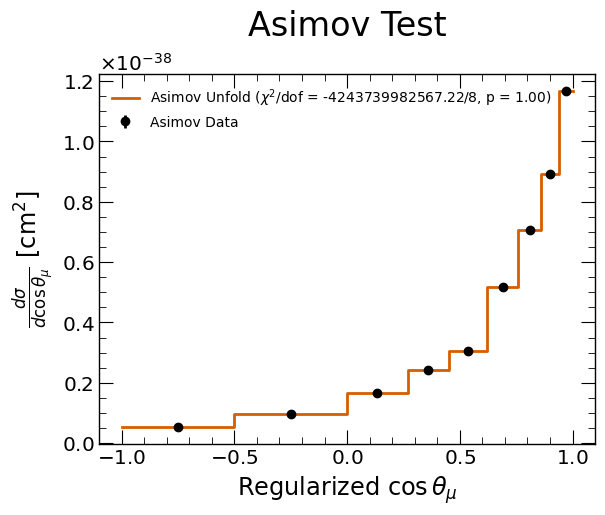

In [476]:
fig,ax = plt.subplots()
makeplot.plot_hist_edges(xsec_asimov_costheta.bins,
  xsec_asimov_costheta.sig_unfold,
  None,
  ax=ax,
  label=f'Asimov Unfold ({xsec_asimov_costheta.chi2_dof_pval_str})',
  )
ax.errorbar(xsec_asimov_costheta.bin_centers,
  xsec_asimov_costheta.sig_smear,
  yerr=xsec_asimov_costheta.sig_smear*xsec_asimov_costheta.unfold_dict['fracunc'],
  label='Asimov Data',c='k',fmt='o')
ax.legend()
ax.set_xlabel(r'Regularized $\cos\theta_\mu$')
ax.set_ylabel(r'$\frac{d\sigma}{d\cos\theta_\mu}$ [cm$^{2}$]')
ax.set_title(f'Asimov Test')
plotters.save_plot('asimov_unfold_costheta',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

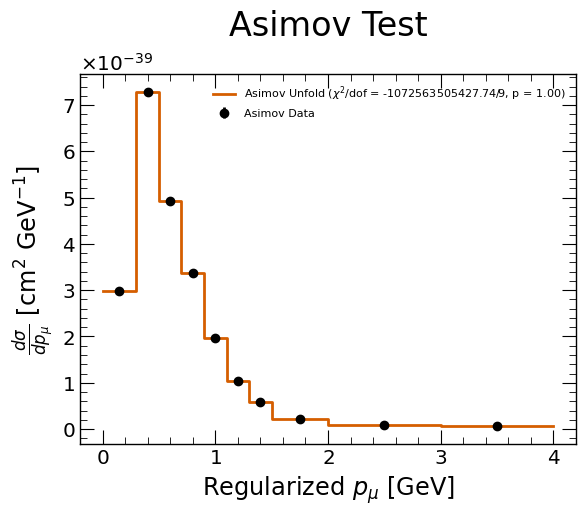

In [477]:
fig,ax = plt.subplots()
makeplot.plot_hist_edges(xsec_asimov_momentum.bins,
  xsec_asimov_momentum.sig_unfold,
  None,
  ax=ax,
  label=f'Asimov Unfold ({xsec_asimov_momentum.chi2_dof_pval_str})',
  )
ax.errorbar(xsec_asimov_momentum.bin_centers,
  xsec_asimov_momentum.sig_smear,
  yerr=xsec_asimov_momentum.sig_smear*xsec_asimov_momentum.unfold_dict['fracunc'],
  label='Asimov Data',c='k',fmt='o')
ax.legend(fontsize=8)
ax.set_xlabel(r'Regularized $p_\mu$ [GeV]')
ax.set_ylabel(r'$\frac{d\sigma}{dp_\mu}$ [cm$^{2}$ GeV$^{-1}$]')
ax.set_title(f'Asimov Test')
plotters.save_plot('asimov_unfold_momentum',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

In [479]:
mbin_centers

array([0.15, 0.4 , 0.6 , 0.9 , 3.5 ])

/tmp/ipykernel_161766/1081758865.py:4: RuntimeWarning: invalid value encountered in multiply
  yerrs=xsec_asimov_differential.sig_smear*xsec_asimov_differential.unfold_dict['fracunc'],


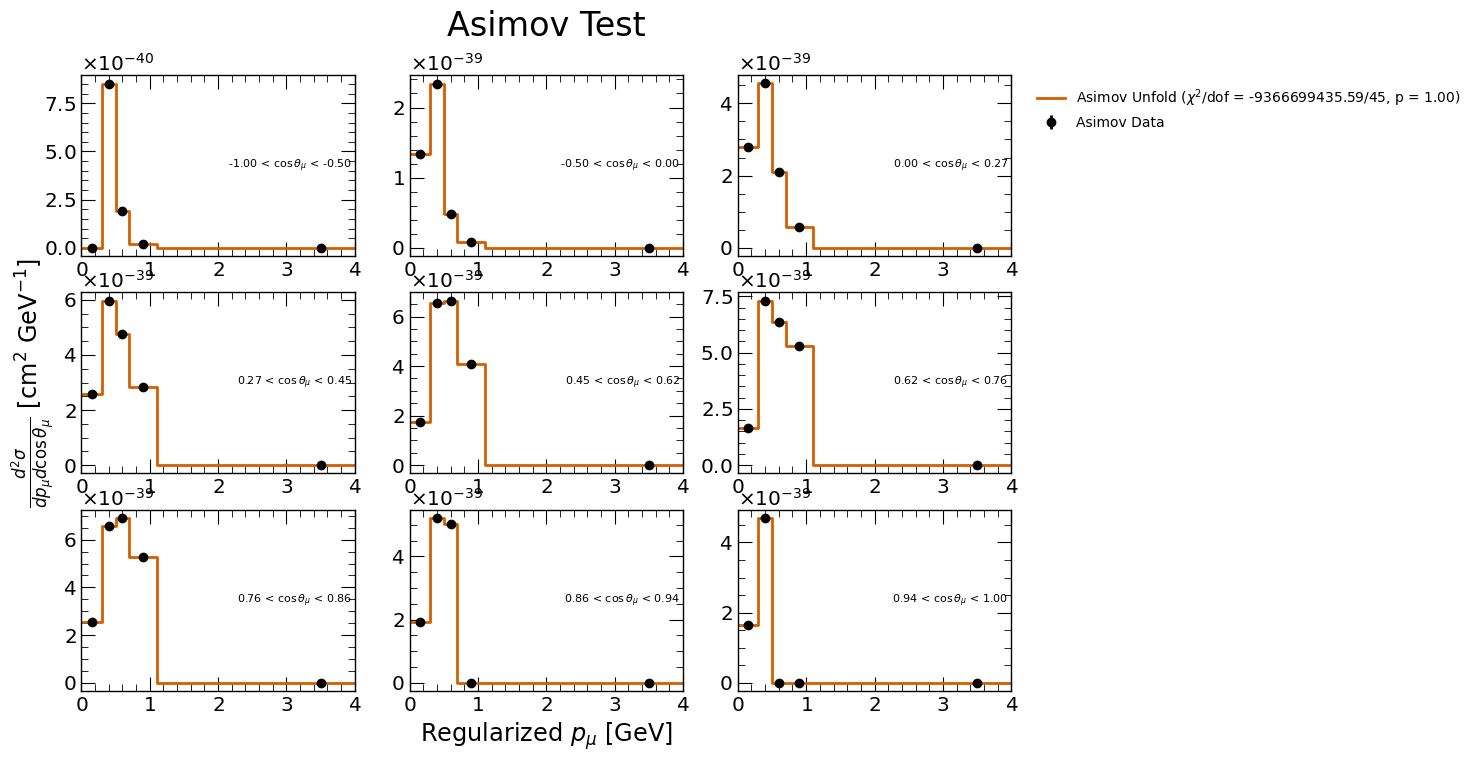

In [517]:
mbin_centers = binning2D.diff_momentum_centers
mbin_centers[-1] = 3.5
fig,axs = binning2D.plot_differential_scatter_binned(xsec_asimov_differential.sig_smear,
  yerrs=xsec_asimov_differential.sig_smear*xsec_asimov_differential.unfold_dict['fracunc'],
  label='Asimov Data',
  bin_centers=mbin_centers,color='k')
fig,axs = binning2D.plot_differential_hist_binned(xsec_asimov_differential.sig_unfold,
  yerrs=None,
  label=f'Asimov Unfold ({xsec_asimov_differential.chi2_dof_pval_str})',
  fig=fig,axs=axs,add_labels=True,legend=True,xlabel=r'Regularized $p_\mu$ [GeV]',
  ylabel=r'$\frac{d^2\sigma}{dp_\mu d\cos\theta_\mu}$ [cm$^{2}$ GeV$^{-1}$]')
axs[0,1].set_title('Asimov Test')
plotters.save_plot('asimov_unfold_differential',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

### 2.2. Scale MEC (fake data)

In [509]:
binning2D.differential_edges

array([-1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,
        9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5,
       20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5,
       31.5, 32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5,
       42.5, 43.5, 44.5])

In [510]:
mec_scale = 1.5

#Signal
mask = slc_mc_sig.data.truth.genie_mode == 10
col = slc_mc_sig.get_key('genweight')
# Variables
genweights_sig = slc_mc_sig.data[col].values.flatten()
genweights_sig_mec = genweights_sig.copy()
genweights_sig_mec[mask]*=mec_scale
costheta_sig_vals = slc_mc_sig.data.truth.mu.dir.z.values
momentum_sig_vals = slc_mc_sig.data.truth.mu.totp.values
diff_sig_vals = slc_mc_sig.data.true_bin.differential.values
# Histograms
costheta_sig_mec,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig_mec)
momentum_sig_mec,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig_mec)
diff_sig_mec,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig_mec)

costheta_sig,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig)
momentum_sig,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig)
diff_sig,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig)

#Selected
mask = slc_mc_sel.data.truth.genie_mode == 10
col = slc_mc_sel.get_key('genweight')
# Variables
genweights_sel = slc_mc_sel.data[col].values.flatten()
genweights_sel_mec = genweights_sel.copy()
genweights_sel_mec[mask]*=mec_scale
costheta_sel_vals = slc_mc_sel.data.truth.mu.dir.z.values
momentum_sel_vals = slc_mc_sel.data.truth.mu.totp.values
diff_sel_vals = slc_mc_sel.data.bin.differential.values
# Histograms
costheta_sel_mec,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel_mec)
momentum_sel_mec,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel_mec)
diff_sel_mec,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel_mec)

costheta_sel,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel)
momentum_sel,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel)
diff_sel,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel)

#Selected signal
m2 = np.isin(slc_mc_sel.data.truth.event_type,[0,1])
#Variables
genweights_sel_sig = genweights_sel[m2]
genweights_sel_sig_mec = genweights_sel_mec[m2]
costheta_sel_sig_vals = costheta_sel_vals[m2]
momentum_sel_sig_vals = momentum_sel_vals[m2]
diff_sel_sig_vals = diff_sel_vals[m2]
# Histograms
costheta_sel_sig_mec,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig_mec)
momentum_sel_sig_mec,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig_mec)
diff_sel_sig_mec,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_mec)

costheta_sel_sig,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig)
momentum_sel_sig,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig)
diff_sel_sig,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig)

# Selected background
costheta_sel_bkg = costheta_sel - costheta_sel_sig
momentum_sel_bkg = momentum_sel - momentum_sel_sig
diff_sel_bkg = diff_sel - diff_sel_sig

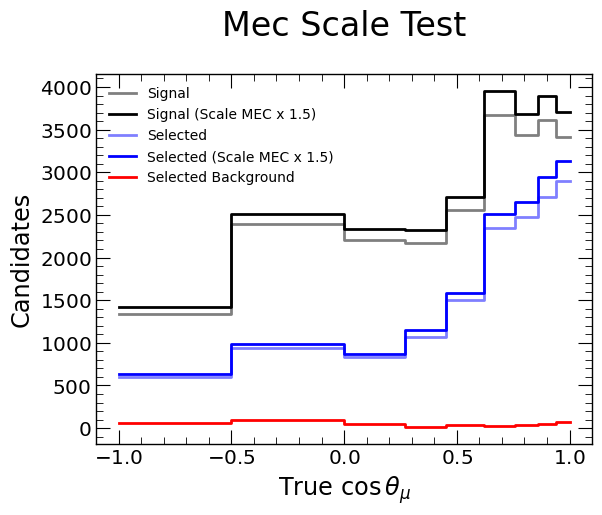

In [514]:
#Check the scaled distributions - costheta
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_mec,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_mec,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)

ax.legend()
ax.set_xlabel(r'True $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title('Mec Scale Test')
plotters.save_plot('mec_scale_eventrate_costheta',fig=fig,folder_name=f'{PLOT_DIR}/mec_scale')


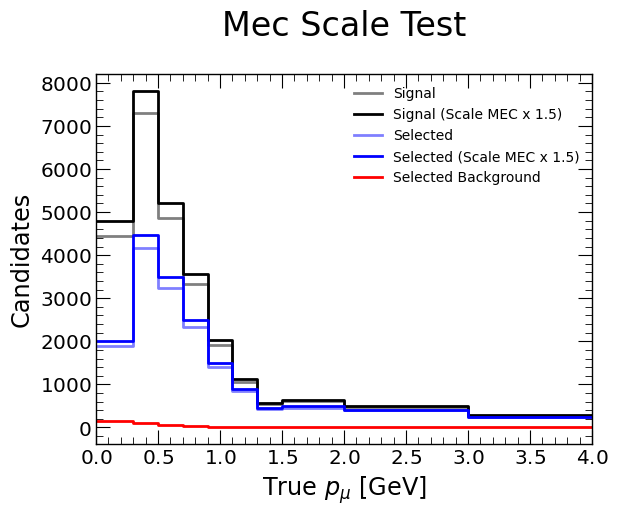

In [515]:
# Check the scaled distributions - momentum
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_mec,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_mec,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)

ax.set_xlim(0,4)
ax.legend()
ax.set_xlabel(r'True $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title('Mec Scale Test')
plotters.save_plot('mec_scale_eventrate_momentum',fig=fig,folder_name=f'{PLOT_DIR}/mec_scale')


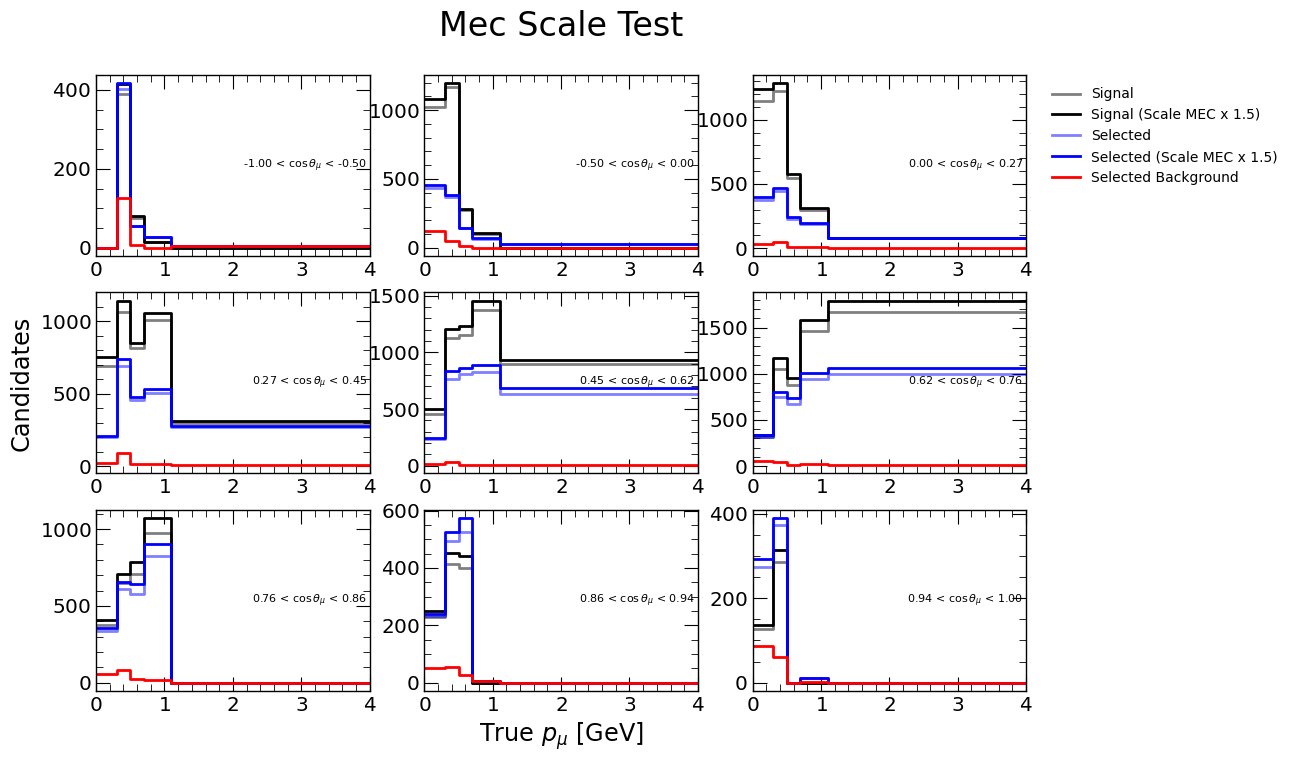

In [518]:
# Check the scaled distributions - differential
fig,axs = binning2D.plot_differential_hist_binned(diff_sig,yerrs=None,label='Signal',color='black',alpha=0.5)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_mec,yerrs=None,label=f'Signal (Scale MEC x {mec_scale})',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_mec,yerrs=None,label=f'Selected (Scale MEC x {mec_scale})',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg,yerrs=None,label='Selected Background',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'True $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Mec Scale Test')
plotters.save_plot('mec_scale_eventrate_differential',fig=fig,folder_name=f'{PLOT_DIR}/mec_scale')

In [ ]:
#Costheta
fracunc_mec = csystematics_rw.systematics['xsec']['xsec_fracunc']
xsec_cov_mec = csystematics_rw.systematics['xsec']['xsec_cov']

xsec_mec_costheta = XSec(
  csystematics_rw.response,  #response
  costheta_sig_mec, #signal
  csystematics_rw.xsec_unit, #xsec unit
  csystematics_rw.bins, #bins
  name='mec test',
  variable='costheta'
  )
xsec_mec_costheta.unfold(xsec_cov_mec, costheta_sel_mec, C_type=C_type, Norm_type=Norm_type,verbose=False)

#Momentum
fracunc_mec = msystematics_rw.systematics['stat']['xsec_fracunc']
xsec_cov_mec = msystematics_rw.systematics['stat']['xsec_cov']
mbins = msystematics_rw.bins #bins
mbins[-1] = 4 #Set last bin to 4 GeV for display purposes

xsec_mec_momentum = XSec(
  msystematics_rw.response,  #response
  momentum_sig_mec, #signal
  msystematics_rw.xsec_unit, #xsec unit
  mbins, #bins
  name='mec test',
  variable='momentum'
  )
xsec_mec_momentum.unfold(xsec_cov_mec, momentum_sel_mec, C_type=C_type, Norm_type=Norm_type,verbose=False)

#Differential
fracunc_mec = dsystematics_rw.systematics['stat']['xsec_fracunc']
xsec_cov_mec = dsystematics_rw.systematics['stat']['xsec_cov']

xsec_mec_differential = XSec(
  dsystematics_rw.response,  #response
  diff_sig_mec, #signal
  dsystematics_rw.xsec_unit, #xsec unit
  dsystematics_rw.bins, #bins
  bin_widths=binning2D.bin_widths, #overwrite bin widths
  name='mec test',
  variable='differential'
  )
xsec_mec_differential.unfold(xsec_cov_mec, diff_sel_mec, C_type=C_type, Norm_type=Norm_type,verbose=False)

### 2.3. Scale QE (fake data)

### 2.4. Remove high momentum muons (fake data)

## 3. Generator comparisons